# مقارنة القوالب:

## الهدف:

** سنتعلم في هذا الفصل : **

* ايجاد الاجسام بالصورة باستخدام مطابقة القوالب

* وسنرى هذه التوابع: **cv2.matchTemplate , cv2.minMaxLoc**


## النظرية:

مقارنة القوالب تتم في OpenCV بتوابع جاهزة , وذلك عن طريق الطي للصورة القالب , مع الصورة الهدف ويكون الخرج صورة رمادية حيث تمثل شدة كل بكسل فيها احتمالية تطابق جواره مع الصورة الاصل , وهناك عدة طرق قد تطبق من خلالها

اذا كانت صورة الاصل بقياس WXH  والصورة القالب : wXh  فان صورة الخرج ستكون بقياس : W-w+1,H-h+1 وعن طريق التابع **cv2.minMaxLoc ** نعرف اقوى موضع للجسم , حيث يكون الناتج هو الزاوية العليا اليسرى للمستطيل المحدد للجسم

_____________________________________________________________
**ملاحظة** اذا استخدمت طريقة `cv2.TM_SQDIFF` فيجب اخذ القيمة الصغرى من الناتج
______________________________________________________________

## مقارنة القوالب في OpenCV

بهذا المثال سنبحث عن وجه ديكارت في الصورة كما يلي:

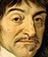

In [3]:
from IPython.display import Image
Image('Rene_Decart_face.jpg')

وسنجرب كل طرق المقارنة كالتالي:

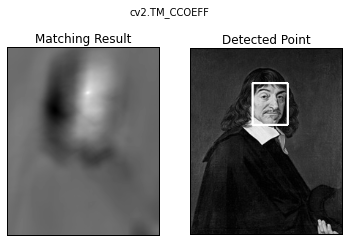

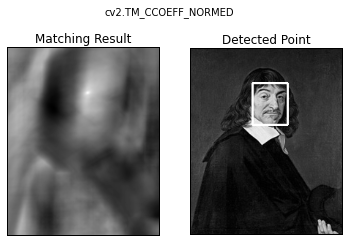

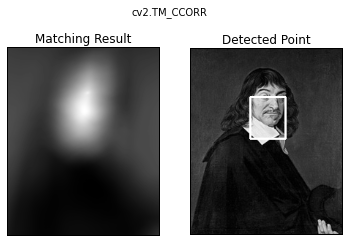

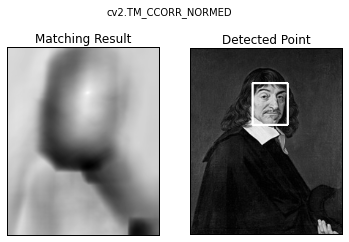

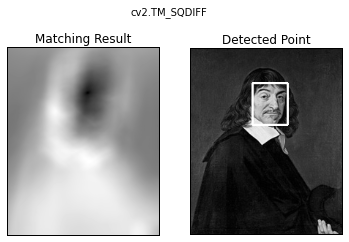

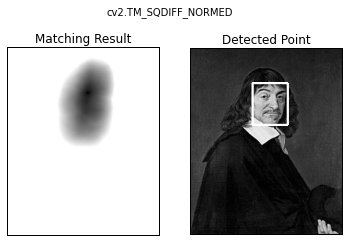

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

img = cv2.imread('Rene_Decart.jpg',0)
img2 = img.copy()
template = cv2.imread('Rene_Decart_face.jpg',0)
w, h = template.shape[::-1]

# All the 6 methods for comparison in a list
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED',
           'cv2.TM_CCORR','cv2.TM_CCORR_NORMED',
           'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

for meth in methods:
    img = img2.copy()
    method = eval(meth)
    # Apply template Matching
    res = cv2.matchTemplate(img,template,method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    
    # If the method is TM_SQDIFF or TM_SQDIFF_NORMED
    # ,take minimum
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)
    
    cv2.rectangle(img,top_left, bottom_right, 255, 2)
    
    plt.subplot(121),plt.imshow(res,cmap = 'gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122),plt.imshow(img,cmap = 'gray')
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth)
    
    
    plt.show()

اذا لاحظت فان الطريقة `cv2.TM_CCORR` ليست جيدة هنا كنظرائها

## مقارنة عدة اجسام معاً :
في السابق بحثنا عن جسم واحد وهو الوجه , ولكن افرض ان لدينا اكثر من جسم نريد ايجاده بالصورة , عندها لن ينفع تابع **cv2.minMaxLoc** ويجب بدلا عنه استخدام التعتيب.
لنأخذ المثال التالي من لعبة ماريو الشهيرة:

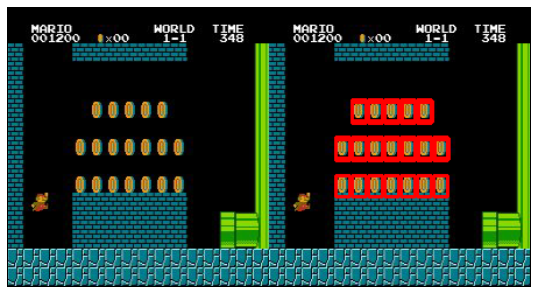

In [13]:

img_rgb = cv2.imread('mario.bmp')
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
original_rgb = img_rgb.copy()

template = cv2.imread('mario_coin.bmp',0)
w, h = template.shape[::-1]

res = cv2.matchTemplate(img_gray,template,cv2.TM_CCOEFF_NORMED)
threshold = 0.8
loc = np.where( res >= threshold)
for pt in zip(*loc[::-1]):
    cv2.rectangle(img_rgb, pt, (pt[0] + w, pt[1] + h),
                  (255,0,0), 2)
    
res  = np.hstack([original_rgb,img_rgb])
plt.figure(figsize=(10,5))

plt.imshow(res)
plt.xticks([])
plt.yticks([])

plt.show()

** مراجع اضافية ** 

** تمارين **